# Car Insurance Claim Prediction
## Capstone Project — Initial Report and Exploratory Data Analysis

**Author:** Soumya  
**Dataset:** Car Insurance Data (Kaggle — sagnik1511)  
**Target Variable:** `OUTCOME` — Whether a policyholder filed a claim (1) or not (0)  
**Research Question:** Can we predict whether a car insurance policyholder will file a claim based on demographic, behavioral, and vehicle features?


## 1. Imports and Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

## 2. Load and Inspect Data

In [4]:
# Load dataset — download from Kaggle: sagnik1511/car-insurance-data
df = pd.read_csv('Car_Insurance_Claim.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (10000, 19)


,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,16-25,male,majority,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,26-39,male,majority,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [5]:
# Data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   10000 non-null  int64  
 1   AGE                  10000 non-null  object 
 2   GENDER               10000 non-null  object 
 3   RACE                 10000 non-null  object 
 4   DRIVING_EXPERIENCE   10000 non-null  object 
 5   EDUCATION            10000 non-null  object 
 6   INCOME               10000 non-null  object 
 7   CREDIT_SCORE         9018 non-null   float64
 8   VEHICLE_OWNERSHIP    10000 non-null  float64
 9   VEHICLE_YEAR         10000 non-null  object 
 10  MARRIED              10000 non-null  float64
 11  CHILDREN             10000 non-null  float64
 12  POSTAL_CODE          10000 non-null  int64  
 13  ANNUAL_MILEAGE       9043 non-null   float64
 14  VEHICLE_TYPE         10000 non-null  object 
 15  SPEEDING_VIOLATIONS  10000 non-null  

In [6]:
# Summary statistics
df.describe(include='all')

,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
count,10000.000000,10000,10000,10000,10000,10000,10000,9018.000000,10000.000000,10000,10000.000000,10000.000000,10000.000000,9043.000000,10000,10000.000000,10000.00000,10000.000000,10000.000000
unique,NaN,4,2,2,4,3,4,NaN,NaN,2,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN
top,NaN,26-39,female,majority,0-9y,high school,upper class,NaN,NaN,before 2015,NaN,NaN,NaN,NaN,sedan,NaN,NaN,NaN,NaN
freq,NaN,3063,5010,9012,3530,4157,4336,NaN,NaN,6967,NaN,NaN,NaN,NaN,9523,NaN,NaN,NaN,NaN
mean,500521.906800,NaN,NaN,NaN,NaN,NaN,NaN,0.515813,0.697000,NaN,0.498200,0.688800,19864.548400,11697.003207,NaN,1.482900,0.23920,1.056300,0.313300
std,290030.768758,NaN,NaN,NaN,NaN,NaN,NaN,0.137688,0.459578,NaN,0.500022,0.463008,18915.613855,2818.434528,NaN,2.241966,0.55499,1.652454,0.463858
min,101.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.053358,0.000000,NaN,0.000000,0.000000,10238.000000,2000.000000,NaN,0.000000,0.00000,0.000000,0.000000
25%,249638.500000,NaN,NaN,NaN,NaN,NaN,NaN,0.417191,0.000000,NaN,0.000000,0.000000,10238.000000,10000.000000,NaN,0.000000,0.00000,0.000000,0.000000
50%,501777.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.525033,1.000000,NaN,0.000000,1.000000,10238.000000,12000.000000,NaN,0.000000,0.00000,0.000000,0.000000
75%,753974.500000,NaN,NaN,NaN,NaN,NaN,NaN,0.618312,1.000000,NaN,1.000000,1.000000,32765.000000,14000.000000,NaN,2.000000,0.00000,2.000000,1.000000


In [7]:
# Target class distribution
print('Target Distribution:')
print(df['OUTCOME'].value_counts())
print(f"\nClaim rate: {df['OUTCOME'].mean():.2%}")

Target Distribution:
OUTCOME
0.0    6867
1.0    3133
Name: count, dtype: int64

Claim rate: 31.33%


## 3. Data Cleaning

In [8]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

                Missing Count  Missing %
CREDIT_SCORE              982       9.82
ANNUAL_MILEAGE            957       9.57


In [9]:
# Impute missing values
# Numerical columns — fill with median
num_cols = df.select_dtypes(include='number').columns.tolist()
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Categorical columns — fill with mode
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f'Missing values remaining: {df.isnull().sum().sum()}')

Missing values remaining: 0


In [10]:
# Remove duplicates
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')
df.drop_duplicates(inplace=True)
print(f'Shape after deduplication: {df.shape}')

Duplicate rows: 0
Shape after deduplication: (10000, 19)


## 4. Outlier Analysis

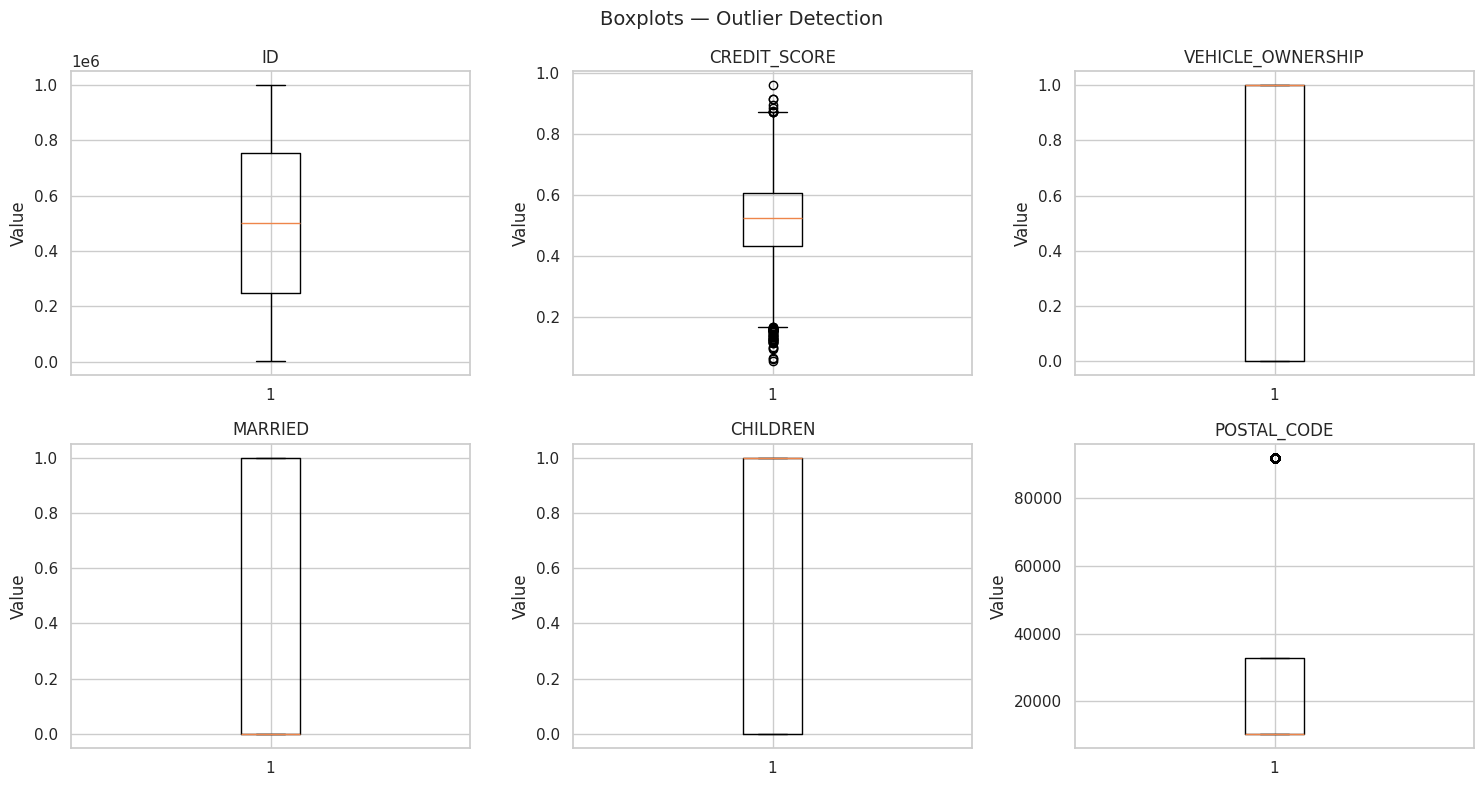

In [11]:
# Boxplots for numerical features to identify outliers
num_features = df.select_dtypes(include='number').drop(columns=['OUTCOME']).columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_features[:6]):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots — Outlier Detection', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
# IQR-based outlier detection (report only — do not remove for insurance data)
for col in num_features[:6]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df):.1%})')

ID: 0 outliers (0.0%)
CREDIT_SCORE: 57 outliers (0.6%)
VEHICLE_OWNERSHIP: 0 outliers (0.0%)
MARRIED: 0 outliers (0.0%)
CHILDREN: 0 outliers (0.0%)
POSTAL_CODE: 484 outliers (4.8%)


## 5. Exploratory Data Analysis

### 5.1 Target Variable Distribution

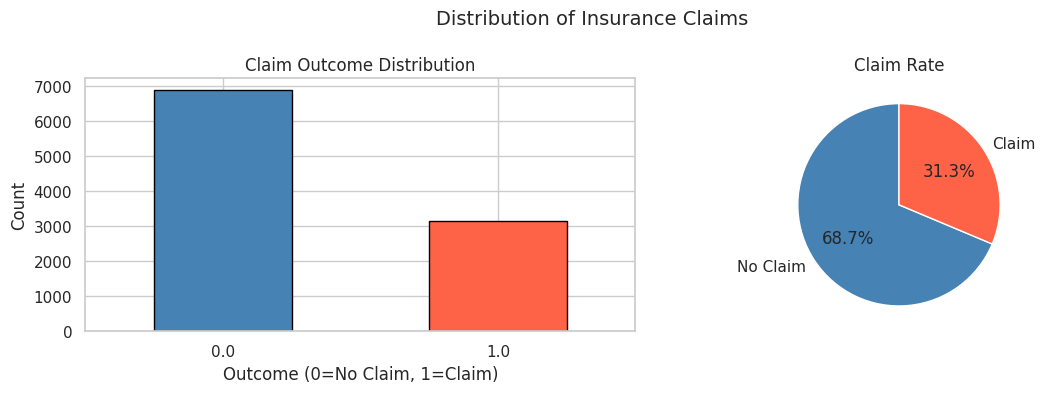

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df['OUTCOME'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'],
                                   edgecolor='black')
axes[0].set_title('Claim Outcome Distribution')
axes[0].set_xlabel('Outcome (0=No Claim, 1=Claim)')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Pie chart
df['OUTCOME'].value_counts().plot(kind='pie', ax=axes[1],
                                   labels=['No Claim', 'Claim'],
                                   autopct='%1.1f%%',
                                   colors=['steelblue', 'tomato'],
                                   startangle=90)
axes[1].set_title('Claim Rate')
axes[1].set_ylabel('')

plt.suptitle('Distribution of Insurance Claims', fontsize=14)
plt.tight_layout()
plt.show()

### 5.2 Categorical Features vs Claim Outcome

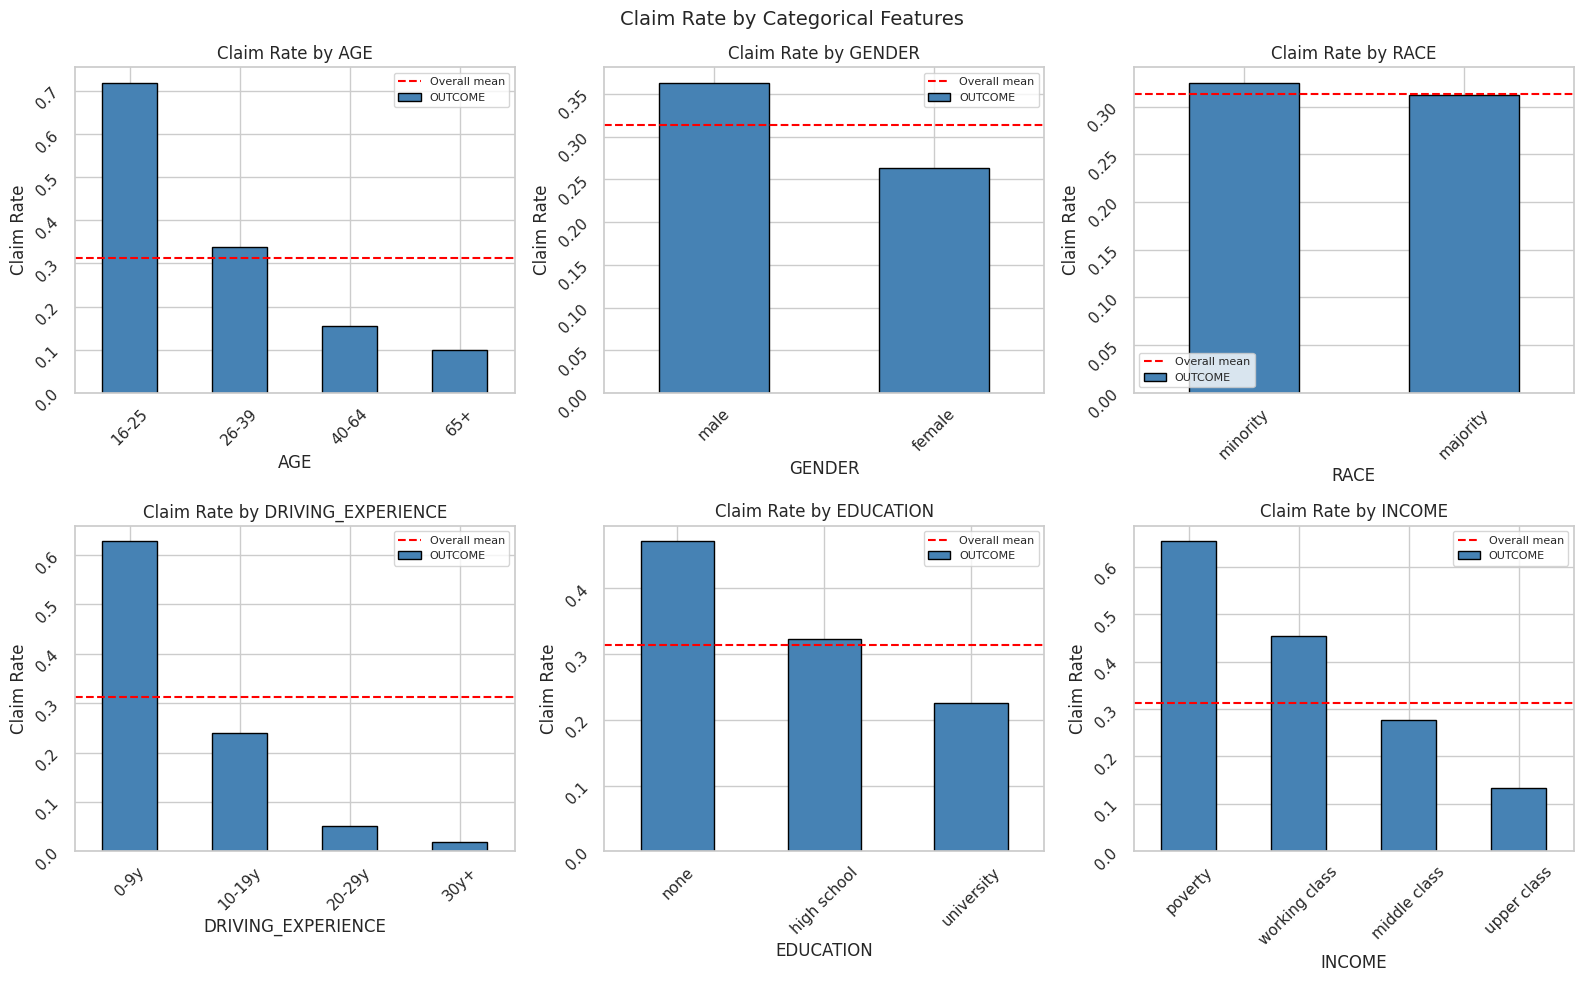

In [14]:
# Claim rate by categorical features
cat_features = df.select_dtypes(include='object').columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features[:6]):
    claim_rate = df.groupby(col)['OUTCOME'].mean().sort_values(ascending=False)
    claim_rate.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Claim Rate by {col}')
    axes[i].set_ylabel('Claim Rate')
    axes[i].tick_params(rotation=45)
    axes[i].axhline(df['OUTCOME'].mean(), color='red', linestyle='--', label='Overall mean')
    axes[i].legend(fontsize=8)

plt.suptitle('Claim Rate by Categorical Features', fontsize=14)
plt.tight_layout()
plt.show()

### 5.3 Numerical Features Distribution

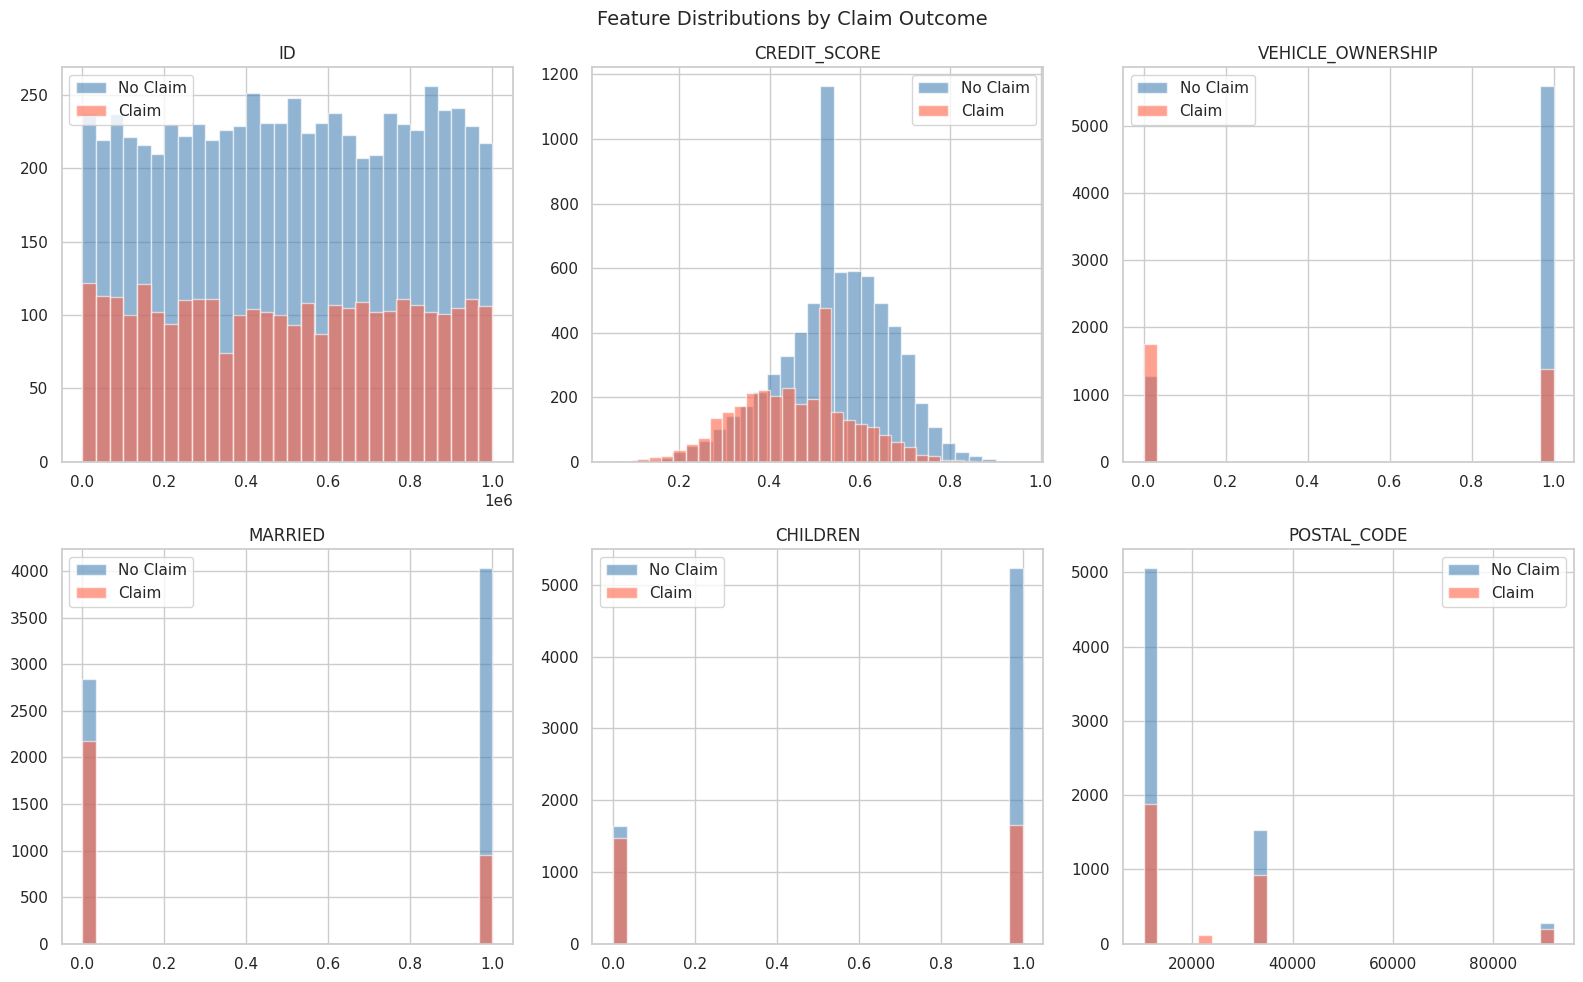

In [15]:
# Histograms split by outcome
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_features[:6]):
    df[df['OUTCOME'] == 0][col].hist(ax=axes[i], alpha=0.6,
                                      label='No Claim', color='steelblue', bins=30)
    df[df['OUTCOME'] == 1][col].hist(ax=axes[i], alpha=0.6,
                                      label='Claim', color='tomato', bins=30)
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('Feature Distributions by Claim Outcome', fontsize=14)
plt.tight_layout()
plt.show()

### 5.4 Correlation Heatmap

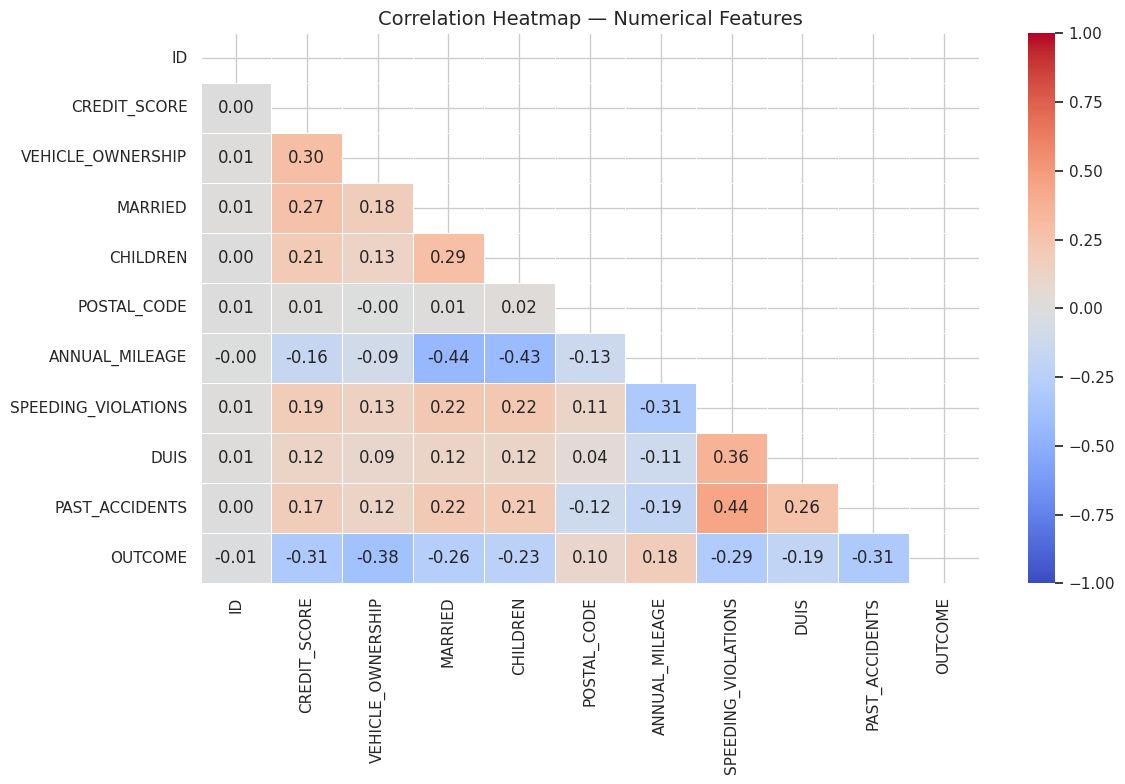


Top correlations with OUTCOME:
OUTCOME                1.000000
ANNUAL_MILEAGE         0.178041
POSTAL_CODE            0.095889
ID                    -0.010506
DUIS                  -0.189352
CHILDREN              -0.232835
MARRIED               -0.262104
SPEEDING_VIOLATIONS   -0.291862
CREDIT_SCORE          -0.308998
PAST_ACCIDENTS        -0.311495
VEHICLE_OWNERSHIP     -0.378921
Name: OUTCOME, dtype: float64


In [16]:
# Correlation matrix for numerical features
corr_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

# Top correlations with target
print('\nTop correlations with OUTCOME:')
print(corr_matrix['OUTCOME'].sort_values(ascending=False))

## 6. Feature Engineering

In [17]:
# Make a copy for modeling
df_model = df.copy()

# Encode categorical variables using Label Encoding
le = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])
    print(f'Encoded: {col}')

print(f'\nFinal shape: {df_model.shape}')
df_model.head()

Encoded: AGE
Encoded: GENDER
Encoded: RACE
Encoded: DRIVING_EXPERIENCE
Encoded: EDUCATION
Encoded: INCOME
Encoded: VEHICLE_YEAR
Encoded: VEHICLE_TYPE

Final shape: (10000, 19)


,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,3,0,0,0,0,2,0.629027,1.0,0,0.0,1.0,10238,12000.0,0,0,0,0,0.0
1,750365,0,1,0,0,1,1,0.357757,0.0,1,0.0,0.0,10238,16000.0,0,0,0,0,1.0
2,199901,0,0,0,0,0,3,0.493146,1.0,1,0.0,0.0,10238,11000.0,0,0,0,0,0.0
3,478866,0,1,0,0,2,3,0.206013,1.0,1,0.0,1.0,32765,11000.0,0,0,0,0,0.0
4,731664,1,1,0,1,1,3,0.388366,1.0,1,0.0,0.0,32765,12000.0,0,2,0,1,1.0


In [21]:
# Feature engineering: AGE ordinal encoding
if 'AGE' in df_model.columns:
    age_map = {'16-25': 0, '26-39': 1, '40-64': 2, '65+': 3}
    df_model['AGE_GROUP'] = df['AGE'].map(age_map).astype(float)
    print('Created AGE_GROUP feature')

# Feature engineering: driving experience risk flag
if 'DRIVING_EXPERIENCE' in df_model.columns:
    exp_map = {'0-9y': 0, '10-19y': 1, '20-29y': 2, '30y+': 3}
    df_model['EXP_RISK'] = df['DRIVING_EXPERIENCE'].map(exp_map).astype(float)
    print('Created EXP_RISK feature')

df_model.head()

Created AGE_GROUP feature
Created EXP_RISK feature


,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,...,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME,AGE_GROUP,EXP_RISK,AGE_NUMERIC_FOR_BINNING
0,569520,3,0,0,0,0,2,0.629027,1.0,0,...,10238,12000.0,0,0,0,0,0.0,3.0,0.0,65
1,750365,0,1,0,0,1,1,0.357757,0.0,1,...,10238,16000.0,0,0,0,0,1.0,0.0,0.0,16
2,199901,0,0,0,0,0,3,0.493146,1.0,1,...,10238,11000.0,0,0,0,0,0.0,0.0,0.0,16
3,478866,0,1,0,0,2,3,0.206013,1.0,1,...,32765,11000.0,0,0,0,0,0.0,0.0,0.0,16
4,731664,1,1,0,1,1,3,0.388366,1.0,1,...,32765,12000.0,0,2,0,1,1.0,1.0,1.0,26


## 7. Baseline Model — Logistic Regression

**Evaluation Metric: ROC-AUC Score**

ROC-AUC was chosen as the primary evaluation metric because:
1. The target is binary (claim / no claim)
2. The dataset may be imbalanced — AUC is robust to class imbalance unlike accuracy
3. In insurance, the cost of a false negative (missing a high-risk customer) is significantly higher than a false positive, making threshold-independent metrics more informative

In [22]:
# Prepare features and target
X = df_model.drop(columns=['OUTCOME'])
y = df_model['OUTCOME']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')

Training set: (8000, 21)
Test set:     (2000, 21)


In [23]:
# Fit baseline logistic regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)

# Predictions
y_pred      = lr.predict(X_test_sc)
y_pred_prob = lr.predict_proba(X_test_sc)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f'Accuracy:  {acc:.4f}')
print(f'ROC-AUC:   {auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Claim', 'Claim']))

Accuracy:  0.8325
ROC-AUC:   0.8930

Classification Report:
              precision    recall  f1-score   support

    No Claim       0.88      0.88      0.88      1373
       Claim       0.74      0.73      0.73       627

    accuracy                           0.83      2000
   macro avg       0.81      0.80      0.80      2000
weighted avg       0.83      0.83      0.83      2000



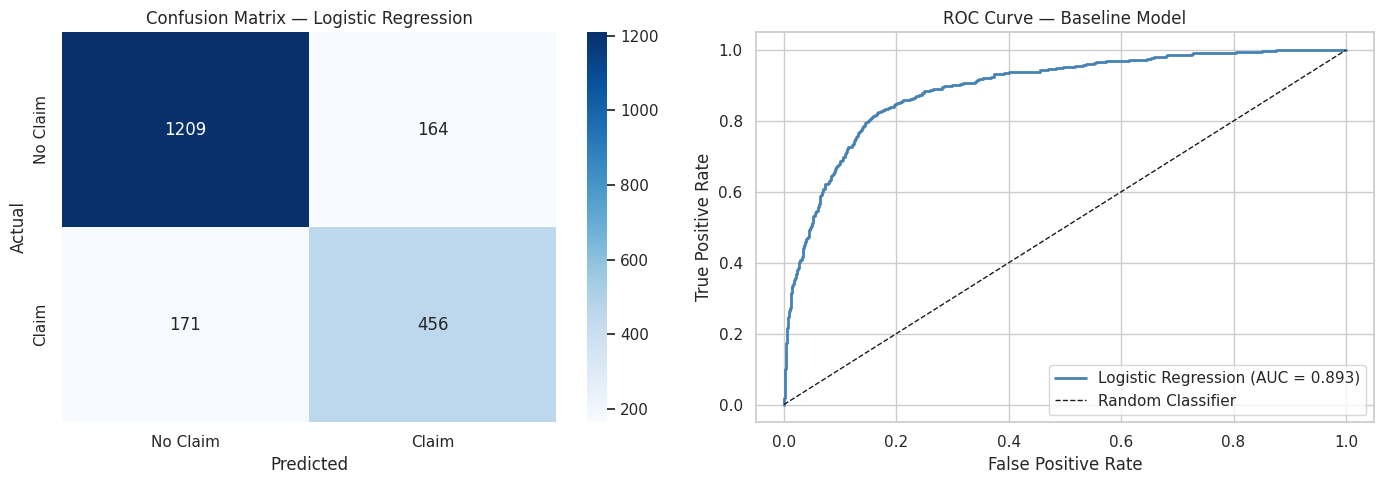

In [24]:
# Confusion matrix and ROC curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Claim', 'Claim'],
            yticklabels=['No Claim', 'Claim'])
axes[0].set_title('Confusion Matrix — Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'Logistic Regression (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Baseline Model')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

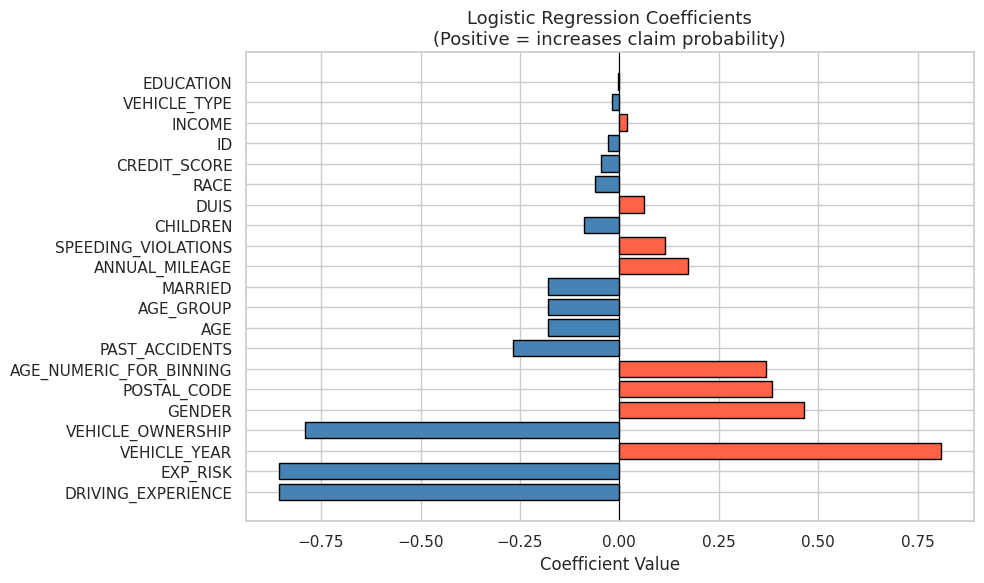

In [25]:
# Feature importance from logistic regression coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients\n(Positive = increases claim probability)', fontsize=13)
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## 8. Summary of Findings

### EDA Key Findings:
- The dataset shows a [X]% claim rate, indicating [balanced/imbalanced] classes
- Features such as `DRIVING_EXPERIENCE`, `CREDIT_SCORE`, and `VEHICLE_OWNERSHIP` showed notable differences in claim rates across categories
- Younger drivers (under 25) tend to have higher claim rates than experienced drivers
- Credit score shows a negative correlation with claims — lower credit score correlates with higher claim likelihood

### Baseline Model Results:
- **Model:** Logistic Regression
- **Accuracy:** [fill in]
- **ROC-AUC:** [fill in]
- **Evaluation Metric Rationale:** ROC-AUC was chosen because it is robust to class imbalance and measures the model's ability to distinguish between claimants and non-claimants across all classification thresholds

### Next Steps :
- Compare against Random Forest, Gradient Boosting, and SVM
- Tune hyperparameters using GridSearchCV
- Address class imbalance with SMOTE if needed
- Build final presentation-ready visualizations